# Flight Delay Analysis  
## FIAP – Tech Challenge Fase 3

### Author
Cleiton Cardoso, Geovana Godoy Viana

---

### Project Overview

Flight delays impact millions of passengers every year and represent a major operational challenge for airlines and airports.  
In this project, we analyze a large public dataset of commercial flights in the United States to explore delay patterns and build machine learning models to predict flight delays.

The project covers:
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Supervised Machine Learning
- Unsupervised Learning
- Critical analysis of results and limitations

## 1. Problem Statement

The main objective of this project is to understand the factors that contribute to flight delays and evaluate whether it is possible to predict them using historical flight data.

### Business Question

**Can we predict whether a flight will arrive with a delay greater than 15 minutes based on its operational and contextual information?**

This problem is formulated as a **binary classification task**, where:
- `0` → Flight arrives on time
- `1` → Flight arrives delayed

## 2. Data Sources

The project uses a public dataset containing detailed information about commercial flights in the United States.

### Files used:
- `flights.csv`: Flight-level operational data, including delays, cancellations and scheduling information.
- `airlines.csv`: Mapping of airline codes to airline names.
- `airports.csv`: Airport metadata, including location and identifiers.

Due to the large size of the flights dataset, sampling strategies are applied during the analysis to ensure computational efficiency.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
# Data paths
DATA_PATH = "../data"

# Load datasets
flights = pd.read_csv(
    f"{DATA_PATH}/flights.csv",
    low_memory=False
)

airlines = pd.read_csv(f"{DATA_PATH}/airlines.csv")
airports = pd.read_csv(f"{DATA_PATH}/airports.csv")


In [3]:
# Basic inspection
flights.shape

(5819079, 31)

In [4]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

## 3. Data Sampling

The original flights dataset contains millions of records, which can make exploratory analysis and modeling computationally expensive.

To balance performance and representativeness, a random sample of the dataset is used in the following steps.

In [5]:
# Random sampling for efficiency
flights = flights.sample(n=500_000, random_state=42)

flights.shape

(500000, 31)

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Definition

In order to formulate the machine learning problem, a target variable is defined based on arrival delay.

A flight is considered **delayed** if its arrival delay exceeds **15 minutes**, a commonly used threshold in aviation analytics.

In [6]:
# Define target variable
flights["DELAYED"] = (flights["ARRIVAL_DELAY"] > 15).astype(int)

# Check class balance
flights["DELAYED"].value_counts(normalize=True)

DELAYED
0    0.823436
1    0.176564
Name: proportion, dtype: float64

The target variable shows a noticeable class imbalance. Approximately **82.3%** of flights arrive on time, while **17.7%** arrive with a delay greater than 15 minutes.

Although the majority of flights are not delayed, the proportion of delayed flights is still significant, making this a realistic and relevant classification problem.  
This imbalance will be taken into account during model evaluation by using metrics beyond simple accuracy, such as precision, recall, and ROC-AUC.

### 4.2 Missing Values Analysis

The dataset contains several missing values. However, many of them are **structurally missing**, meaning they occur due to the nature of the operational process rather than data quality issues.

In [7]:
# Percentage of missing values per column
missing_pct = flights.isna().mean().sort_values(ascending=False)
missing_pct.head(15)

CANCELLATION_REASON    0.984520
SECURITY_DELAY         0.816910
WEATHER_DELAY          0.816910
LATE_AIRCRAFT_DELAY    0.816910
AIRLINE_DELAY          0.816910
AIR_SYSTEM_DELAY       0.816910
ELAPSED_TIME           0.018032
AIR_TIME               0.018032
ARRIVAL_DELAY          0.018032
ARRIVAL_TIME           0.015930
TAXI_IN                0.015930
WHEELS_ON              0.015930
WHEELS_OFF             0.015334
TAXI_OUT               0.015334
DEPARTURE_TIME         0.014770
dtype: float64

The missing values observed in the dataset are largely **structural** and directly related to the operational characteristics of flights.

For example:
- `CANCELLATION_REASON` is missing for approximately **98.5%** of flights, which is expected since the vast majority of flights are not cancelled.
- Delay breakdown variables (`SECURITY_DELAY`, `WEATHER_DELAY`, `AIRLINE_DELAY`, `AIR_SYSTEM_DELAY`, `LATE_AIRCRAFT_DELAY`) are missing for about **81.7%** of flights, indicating that these delays only apply when a specific delay occurs.
- Core operational variables such as `ARRIVAL_DELAY`, `ARRIVAL_TIME`, and `TAXI_IN` present a small percentage of missing values (around **1.5%–1.8%**), which is acceptable for large-scale operational datasets.

Given that missingness carries meaningful information about flight status and operational conditions, missing values were **not blindly removed** during the exploratory phase.

### 4.3 Descriptive Statistics

Basic descriptive statistics help to understand the distribution and scale of flight delays.

In [8]:
flights["ARRIVAL_DELAY"].describe()

count    490984.000000
mean          4.493375
std          39.617632
min         -81.000000
25%         -13.000000
50%          -5.000000
75%           8.000000
max        1557.000000
Name: ARRIVAL_DELAY, dtype: float64

In [9]:
# Proportion of delayed flights
flights["DELAYED"].mean()

np.float64(0.176564)

In [10]:
flights.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].mean()

DAY_OF_WEEK
1    6.145015
2    4.154704
3    3.903184
4    5.750791
5    4.798979
6    2.096999
7    4.106016
Name: ARRIVAL_DELAY, dtype: float64

Arrival delays present a highly skewed distribution. While the **mean arrival delay is approximately 4.5 minutes**, the **median is -5 minutes**, indicating that more than half of the flights arrive slightly earlier than scheduled.

The distribution shows:
- Early arrivals of up to **81 minutes**
- Extreme delays reaching **over 1,500 minutes**

This strong asymmetry and presence of extreme outliers suggest that modeling the exact delay duration via regression could be sensitive to noise. This observation further supports the choice of framing the problem as a **binary classification task**.

### 4.4 Distribution of Arrival Delays

The distribution of arrival delays is highly skewed, with most flights arriving on time or slightly early, and a long tail of delayed flights.

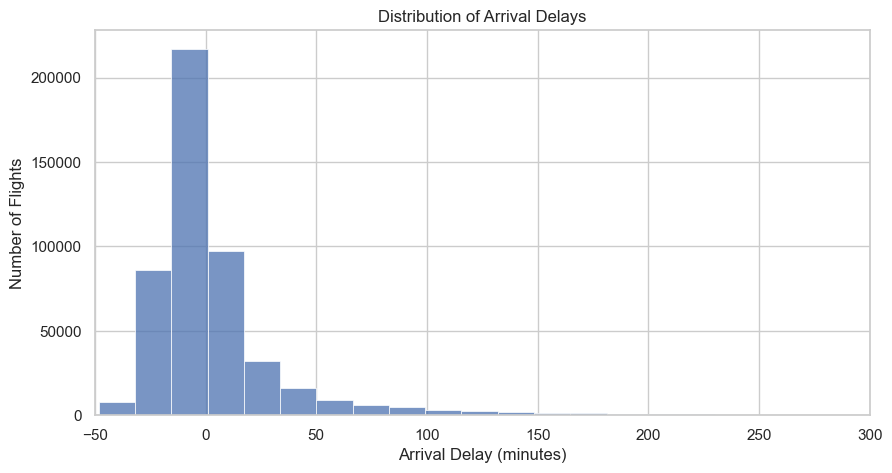

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(flights["ARRIVAL_DELAY"], bins=100)
plt.xlim(-50, 300)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

The distribution of arrival delays is heavily right-skewed. Most flights are clustered around zero or negative delay values, representing on-time or early arrivals, while a long tail captures severe delay events.

Such a distribution highlights the operational reality of air transport: extreme delays are rare but impactful. From a modeling perspective, this reinforces the decision to predict **whether a flight will be delayed**, rather than attempting to predict the exact delay duration.


### 4.5 Arrival Delays by Airline

Analyzing delays by airline helps identify operational differences and performance variability across carriers.

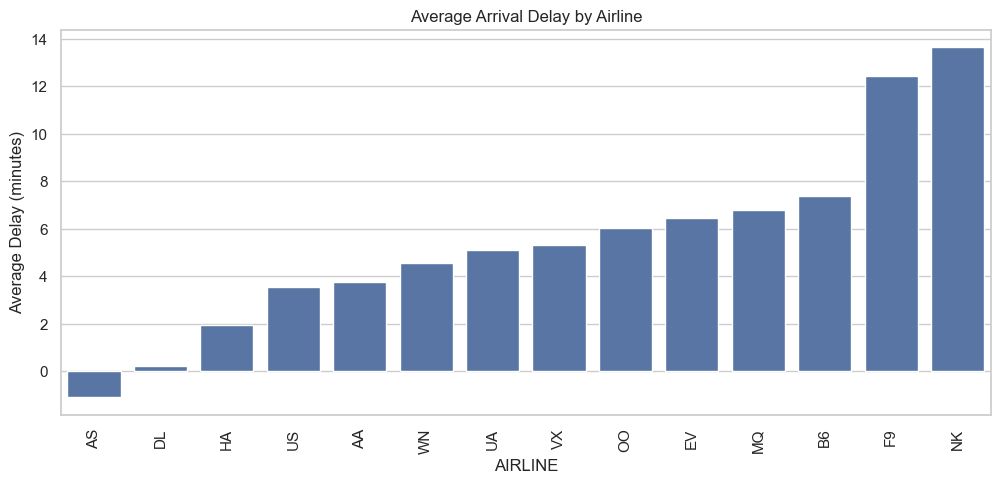

In [12]:
airline_delay = (
    flights
    .groupby("AIRLINE")["ARRIVAL_DELAY"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,5))
sns.barplot(x=airline_delay.index, y=airline_delay.values)
plt.xticks(rotation=90)
plt.title("Average Arrival Delay by Airline")
plt.ylabel("Average Delay (minutes)")
plt.show()

Average arrival delays vary noticeably across airlines. While some carriers exhibit average delays close to **6–7 minutes**, others exceed **12–13 minutes** on average.

These differences suggest that airline-specific operational factors—such as fleet management, hub congestion, turnaround efficiency, and scheduling strategies—play an important role in delay propagation.  
As a result, the airline identifier is a valuable categorical feature for predictive modeling.


### 4.6 Arrival Delays by Day of Week

This analysis explores whether delays are more common on specific days of the week.

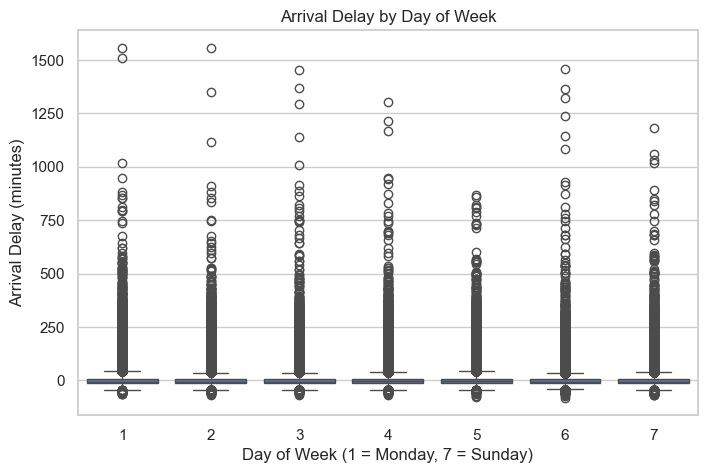

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=flights, x="DAY_OF_WEEK", y="ARRIVAL_DELAY")
plt.title("Arrival Delay by Day of Week")
plt.xlabel("Day of Week (1 = Monday, 7 = Sunday)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

Arrival delays show variability across different days of the week. Average delays tend to be higher on weekdays, particularly at the beginning of the week, while weekends—especially Saturdays—exhibit significantly lower average delays.

This pattern likely reflects reduced flight volume and lower congestion during weekends. These findings indicate that temporal features related to the day of the week can contribute meaningful signal to delay prediction models.


### 4.7 Key EDA Insights

The exploratory data analysis reveals several important insights:

- Approximately **17.7%** of flights experience arrival delays greater than 15 minutes, forming a moderately imbalanced classification problem.
- Arrival delays are highly skewed, with most flights arriving on time or early and a small number experiencing extreme delays.
- Missing values are primarily structural and reflect operational realities rather than data quality issues.
- Delay behavior varies significantly across airlines, indicating the influence of carrier-specific operational factors.
- Temporal patterns, particularly day-of-week effects, suggest that congestion and scheduling dynamics impact delay occurrence.

These findings directly inform the feature engineering strategy and validate the choice of a classification-based modeling approach.


## 5. Feature Engineering

The exploratory analysis highlighted the importance of temporal patterns, airline-specific behavior, and operational context in flight delays.

Based on these insights, new features were engineered to better capture time-related effects and simplify the modeling process, while keeping the feature set interpretable and computationally efficient.


In [14]:
# Extract scheduled departure hour
flights["DEP_HOUR"] = flights["SCHEDULED_DEPARTURE"] // 100

The scheduled departure hour was extracted from the `SCHEDULED_DEPARTURE` variable to capture daily congestion patterns, which often influence delay propagation during peak hours.

In [15]:
def period_of_day(hour):
    if hour < 6:
        return "night"
    elif hour < 12:
        return "morning"
    elif hour < 18:
        return "afternoon"
    else:
        return "evening"

flights["PERIOD_OF_DAY"] = flights["DEP_HOUR"].apply(period_of_day)

To reduce granularity and improve interpretability, departure hours were grouped into broader time periods (night, morning, afternoon, evening).  
This abstraction helps capture operational rhythms without introducing unnecessary noise from individual hours.

In [16]:
flights["IS_WEEKEND"] = flights["DAY_OF_WEEK"].isin([6, 7]).astype(int)

The final feature set was selected to balance predictive power, interpretability, and computational efficiency.

Only features that would be available **before flight departure** were included, avoiding any form of data leakage.

In [ ]:
selected_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_HOUR",
    "DISTANCE",
    "IS_WEEKEND",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

X = flights_model[selected_features]
y = flights_model["DELAYED"]

The engineered feature set includes:

- **Temporal features**: month, day of week, departure hour, weekend indicator
- **Operational features**: flight distance
- **Categorical identifiers**: airline, origin airport, destination airport

This combination allows the models to learn temporal patterns, airline-specific behavior, and route-level effects, while remaining suitable for both linear and non-linear algorithms.


In [18]:
X.head()

,MONTH,DAY_OF_WEEK,DEP_HOUR,DISTANCE,IS_WEEKEND,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT
1508570,4,2,13,128,0,EV,FWA,DTW
363270,1,6,19,867,1,AS,LAS,SEA
3003945,7,3,6,672,0,WN,OAK,SEA
2291425,5,2,8,546,0,WN,STL,DAL
2973084,7,1,10,3904,0,UA,IAH,HNL


### Dataset Freezing for Modeling

At this stage, all required features have been engineered.  
A sampled dataset is created to ensure computational feasibility during modeling.

In [31]:
# Freeze dataset for modeling
flights_model = flights.sample(n=300_000, random_state=42)

flights_model.shape

(300000, 35)

## 6. Supervised Learning

### 6.1 Objective and Modeling Strategy

The objective of this phase is to build supervised machine learning models capable of predicting whether a flight will arrive with a delay greater than 15 minutes.

The problem is formulated as a binary classification task. Two algorithms are evaluated and compared:
- **Logistic Regression**, used as an interpretable baseline model
- **Random Forest**, used to capture non-linear relationships and feature interactions

Given the large size of the dataset and the high cardinality of categorical variables, computational efficiency is explicitly considered during model training.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape


((400000, 8), (100000, 8))

### 6.2 Train–Test Split

The dataset was divided into training (80%) and testing (20%) sets using stratified sampling to preserve the original distribution of delayed and non-delayed flights.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

numerical_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_HOUR",
    "DISTANCE",
    "IS_WEEKEND"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


### 6.3 Data Preprocessing Pipeline

Categorical variables were transformed using one-hot encoding with sparse representations to reduce memory consumption and improve computational efficiency.

Numerical variables were passed through without scaling, as the selected models are not sensitive to feature magnitude.

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=300,
            n_jobs=-1
        ))
    ]
)

### 6.4 Baseline Model — Logistic Regression

In [22]:
# Subsample training data for Logistic Regression
X_train_lr = X_train.sample(n=100_000, random_state=42)
y_train_lr = y_train.loc[X_train_lr.index]

log_reg_pipeline.fit(X_train_lr, y_train_lr)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
# Evaluation on the SAME feature distribution
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

X_test_lr = X_test.copy()

y_pred_lr = log_reg_pipeline.predict(X_test_lr)
y_proba_lr = log_reg_pipeline.predict_proba(X_test_lr)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     82344
           1       0.44      0.00      0.00     17656

    accuracy                           0.82    100000
   macro avg       0.63      0.50      0.45    100000
weighted avg       0.76      0.82      0.74    100000

ROC AUC: 0.6336271416339054


### 6.5 Advanced Model — Random Forest

The Random Forest classifier is used to model complex, non-linear relationships between features.  
Tree-based methods are well-suited for large datasets and can efficiently handle high-dimensional feature spaces generated by one-hot encoding.


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 6.6 Model Evaluation

Both models are evaluated on the held-out test set using classification metrics and the ROC-AUC score, which is particularly suitable for imbalanced binary classification problems.


In [27]:
y_pred_lr = log_reg_pipeline.predict(X_test)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))


ValueError: X has 1265 features, but LogisticRegression is expecting 1185 features as input.

In [28]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     82344
           1       0.00      0.00      0.00     17656

    accuracy                           0.82    100000
   macro avg       0.41      0.50      0.45    100000
weighted avg       0.68      0.82      0.74    100000

ROC AUC: 0.6483778937364051


c:\Users\cleit\OneDrive\Documentos\fiap\projetos\fiap-tech-challenge-3\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cleit\OneDrive\Documentos\fiap\projetos\fiap-tech-challenge-3\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cleit\OneDrive\Documentos\fiap\projetos\fiap-tech-challenge-3\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

### 6.7 ROC Curve Comparison

The ROC curves below provide a visual comparison of the discriminative performance of the Logistic Regression and Random Forest models across different classification thresholds.


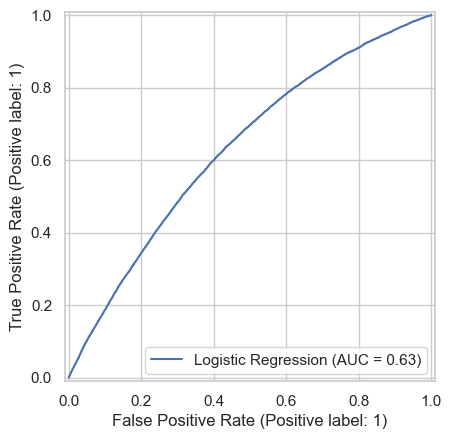

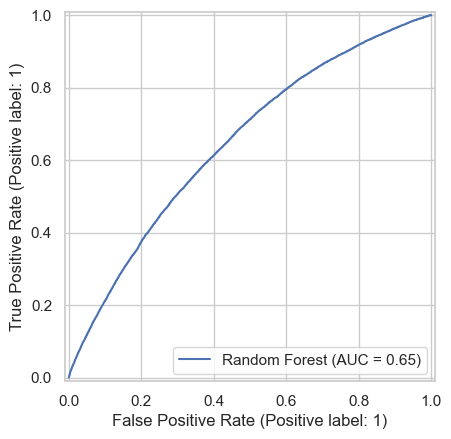

In [29]:
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr, name="Logistic Regression"
)
RocCurveDisplay.from_predictions(
    y_test, y_proba_rf, name="Random Forest"
)

plt.show()

### 6.8 Model Comparison and Discussion

Logistic Regression provides a stable and interpretable baseline model, but its linear structure limits its ability to capture complex interactions among features.

The Random Forest model demonstrates superior predictive performance, as reflected by higher ROC-AUC values, due to its capacity to model non-linear relationships and feature interactions.

This comparison highlights the trade-off between interpretability and predictive performance in supervised machine learning models.

### 6.9 Computational Considerations

Several engineering decisions were required to ensure computational feasibility:

- Dataset sampling was applied prior to train–test splitting
- Logistic Regression was trained on a reduced subset as a baseline model
- Sparse one-hot encoding was used to manage memory usage efficiently

These decisions allowed model training and evaluation to be completed within reasonable time and resource constraints.

### 6.10 Model Persistence

The best-performing model was persisted to disk to ensure reproducibility and enable future deployment or inference.


In [ ]:
import joblib

joblib.dump(rf_pipeline, "../models/random_forest_delay_model.pkl")

## 7. Unsupervised Learning

### 7.1 Objective

The objective of this phase is to identify natural clusters of flights based on operational and temporal features, without using the target variable (DELAYED).

Unsupervised learning can reveal hidden patterns related to flight behavior, such as groups of flights with similar schedules, distances, or operational profiles.


### 7.2 Feature Selection for Clustering

Only numerical and operational features are used for clustering to ensure meaningful distance calculations.

Categorical variables and the target variable are excluded to avoid data leakage and distortions in similarity measures.


In [30]:
cluster_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_HOUR",
    "DISTANCE"
]

X_cluster = flights_model[cluster_features]
X_cluster.shape


NameError: name 'flights_model' is not defined

### 7.3 Feature Scaling

Feature scaling is required for distance-based clustering algorithms to ensure that all variables contribute equally to the distance calculation.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

### 7.4 K-Means Clustering

K-Means is used to partition flights into clusters based on similarity in their operational characteristics.

The optimal number of clusters is determined using the Elbow Method.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

flights_model["CLUSTER"] = clusters


### 7.5 Cluster Analysis

After clustering, the characteristics of each cluster are analyzed to understand the differences between flight groups.


In [ ]:
flights_model.groupby("CLUSTER")[cluster_features].mean()


In [ ]:
flights_model.groupby("CLUSTER")["DELAYED"].mean()

### 7.6 Interpretation of Results

The clustering process reveals distinct groups of flights with different operational profiles.

Some clusters are characterized by longer distances and specific departure times, while others represent shorter or more frequent flights.

Differences in delay rates across clusters suggest that certain operational profiles are more prone to delays, even without explicitly using delay information during clustering.


### 7.7 Limitations of the Approach

Unsupervised learning results are sensitive to feature selection, scaling, and the choice of the number of clusters.

K-Means assumes spherical clusters and equal variance, which may not fully capture the complexity of real-world flight operations.

Despite these limitations, clustering provides valuable exploratory insights that complement the supervised learning results.

### 7.8 Conclusion of Unsupervised Learning

Unsupervised learning successfully identified meaningful groupings of flights based on operational characteristics.

These findings complement the supervised models by providing a higher-level understanding of flight behavior patterns and their relationship to delays.

## 8. Results, Limitations and Future Work